In [1]:
import sys
import pandas as pd
sys.path.append("..")
from utils.market_data import get_candles

In [41]:
from datetime import date

ticker1 = "SBER"
ticker1_api_params = ["stock", "shares", "TQBR"]

ticker2 = "SBERF"
ticker2_api_params = ["futures", "forts", "RFUD"]

start_date = date(2024, 11, 2)
end_date = date(2026, 5, 23)

In [42]:
df1 = get_candles(ticker1, start_date, end_date, engine=ticker1_api_params[0], market=ticker1_api_params[1], board=ticker1_api_params[2], interval=10)
df2 = get_candles(ticker2, start_date, end_date, engine=ticker2_api_params[0], market=ticker2_api_params[1], board=ticker2_api_params[2], interval=10)

print(df1.head(1))
print(df2.head(1))

Number of deleted duplicates: 14608
Number of deleted duplicates: 12004
                      open  close   high    low       value  volume  \
timestamp                                                             
2024-11-02 09:50:00  237.9  237.9  237.9  237.9  10053654.0   42260   

                                     end  
timestamp                                 
2024-11-02 09:50:00  2024-11-02 09:59:59  
                       open   close    high     low  value  volume  \
timestamp                                                            
2024-11-02 09:50:00  238.45  238.45  238.45  238.45      0       1   

                                     end  
timestamp                                 
2024-11-02 09:50:00  2024-11-02 09:59:59  


In [43]:
df1.sort_values(by="timestamp", inplace=True)
df2.sort_values(by="timestamp", inplace=True)

df = pd.merge_asof(
    df1,
    df2,
    left_on="timestamp",
    right_on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("1m")
)
df.head(1)

,timestamp,open_x,close_x,high_x,low_x,value_x,volume_x,end_x,open_y,close_y,high_y,low_y,value_y,volume_y,end_y
0,2024-11-02 09:50:00,237.9,237.9,237.9,237.9,10053654.0,42260,2024-11-02 09:59:59,238.45,238.45,238.45,238.45,0.0,1.0,2024-11-02 09:59:59


In [44]:
df = df[["timestamp", "close_x", "close_y"]]
df["spread"] = df["close_y"] - df["close_x"]

Text(0.5, 1.0, 'Spread between SBER and SBERF')

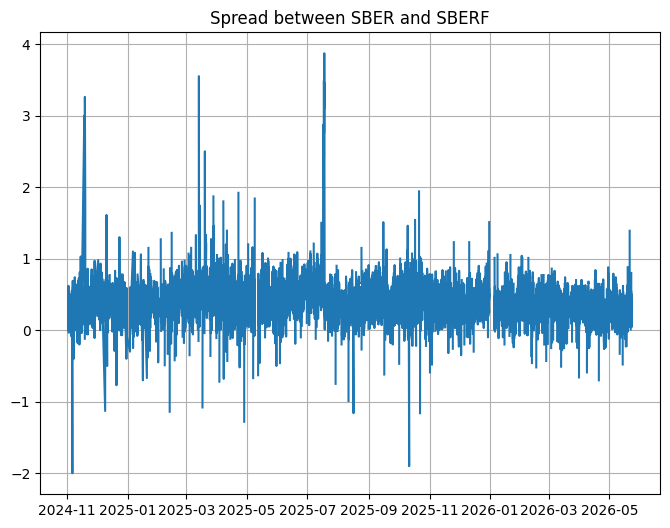

In [45]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(8,6))
plt.plot(df['timestamp'], df['spread'])
plt.grid()
plt.title(f"Spread between {ticker1} and {ticker2}")

In [46]:
window=40
df['rolling_mean'] = df['spread'].rolling(window=window).mean()
df['rolling_std'] = df['spread'].rolling(window=window).std()

df['z_score'] = (df['spread'] - df['rolling_mean'])/df['rolling_std']

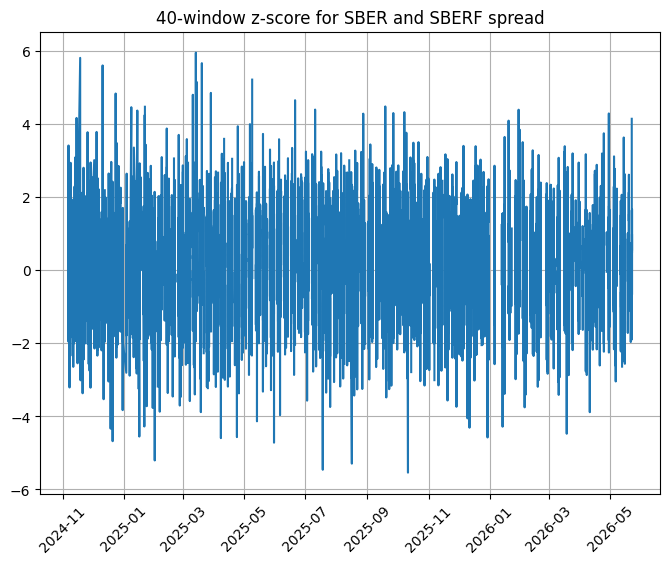

In [47]:
fig = plt.figure(figsize=(8,6))

plt.plot(df['timestamp'], df['z_score'])
plt.xticks(rotation=45)
plt.title(f"{window}-window z-score for {ticker1} and {ticker2} spread")
plt.grid()
plt.show()